Using GPU: Tesla T4

Polynomial degree: 1
lambda1=0.1, lambda2=1.0, CV RMSE=6.327401
lambda1=0.1, lambda2=1.25, CV RMSE=6.327383
lambda1=0.1, lambda2=1.5, CV RMSE=6.327366
lambda1=0.1, lambda2=1.75, CV RMSE=6.327349
lambda1=0.1, lambda2=2.0, CV RMSE=6.327332
lambda1=0.1, lambda2=2.5, CV RMSE=6.327299
lambda1=0.1, lambda2=3.0, CV RMSE=6.327267
lambda1=0.15, lambda2=1.0, CV RMSE=6.327401
lambda1=0.15, lambda2=1.25, CV RMSE=6.327383
lambda1=0.15, lambda2=1.5, CV RMSE=6.327366
lambda1=0.15, lambda2=1.75, CV RMSE=6.327349
lambda1=0.15, lambda2=2.0, CV RMSE=6.327332
lambda1=0.15, lambda2=2.5, CV RMSE=6.327299
lambda1=0.15, lambda2=3.0, CV RMSE=6.327267
lambda1=0.2, lambda2=1.0, CV RMSE=6.327401
lambda1=0.2, lambda2=1.25, CV RMSE=6.327384
lambda1=0.2, lambda2=1.5, CV RMSE=6.327366
lambda1=0.2, lambda2=1.75, CV RMSE=6.327349
lambda1=0.2, lambda2=2.0, CV RMSE=6.327332
lambda1=0.2, lambda2=2.5, CV RMSE=6.327299
lambda1=0.2, lambda2=3.0, CV RMSE=6.327268
lambda1=0.25, lambda2=1.0, CV RMSE=6.32740

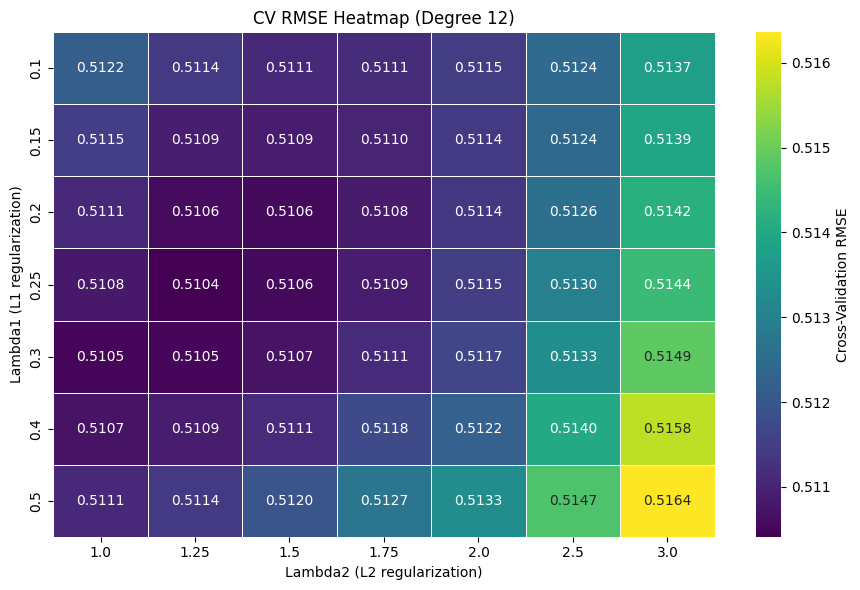

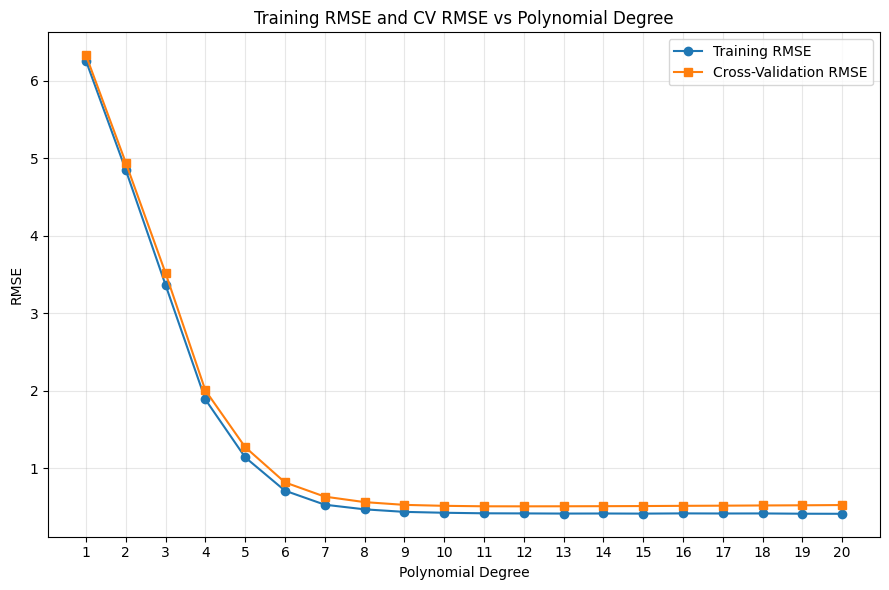


Final Model Performance
-----------------------
Training RMSE: 0.41912071341484847
Training R^2: 0.9967842834122419

Files saved:
- var2_elasticnet_comparison.csv
- var2_lambda_heatmap.png
- var2_degree_error_plot.png
- polynomial_coefficients_var2.csv
- polynomial_model_var2.pkl


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score

# ------------------------------------------
# GPU setup
# ------------------------------------------

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is not available.")

device = torch.device("cuda")
dtype = torch.float64

print("Using GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------
# Load training data
# ------------------------------------------

train = pd.read_csv("BT2024031_train_var2.csv")

X = train[["x1", "x2", "x3"]].values
y = train["y"].values.reshape(-1, 1)


# ------------------------------------------
# Hyperparameter search
# ------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = range(1, 21)

lambda1_values = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
lambda2_values = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]

MAX_ITER = 800
TOL = 1e-4


# ------------------------------------------
# Elastic Net using GPU-based FISTA
# ------------------------------------------

def train_model(X_train, y_train, lambda1, lambda2):

    X_train = np.asarray(X_train, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64).reshape(-1, 1)

    n_samples, n_features = X_train.shape

    # Center X and y to calculate intercept separately
    x_mean = X_train.mean(axis=0, keepdims=True)
    y_mean = y_train.mean()

    X_centered = X_train - x_mean
    y_centered = y_train - y_mean

    # Transfer centered data to GPU
    X_gpu = torch.tensor(
        X_centered,
        dtype=dtype,
        device=device
    )

    y_gpu = torch.tensor(
        y_centered,
        dtype=dtype,
        device=device
    )

    # Calculate Lipschitz constant once
    spectral_norm = torch.linalg.matrix_norm(X_gpu, ord=2)

    L = 2 * (spectral_norm ** 2 + lambda2)

    if L.item() == 0:
        weights = np.zeros((n_features, 1))
        intercept = y_mean
        return weights, np.array([intercept])

    step_size = 1.0 / L

    # Initialize weights on GPU
    weights = torch.zeros(
        (n_features, 1),
        dtype=dtype,
        device=device
    )

    z = weights.clone()
    t = 1.0

    for iteration in range(MAX_ITER):

        # Gradient of smooth part
        gradient = (
            2 * X_gpu.T @ (X_gpu @ z - y_gpu)
            + 2 * lambda2 * z
        )

        # Gradient descent step
        v = z - step_size * gradient

        # Proximal operator for L1 penalty
        new_weights = torch.sign(v) * torch.clamp(
            torch.abs(v) - step_size * lambda1,
            min=0.0
        )

        # FISTA acceleration
        new_t = (1 + np.sqrt(1 + 4 * t**2)) / 2

        z_new = new_weights + (
            (t - 1) / new_t
        ) * (new_weights - weights)

        # Convergence check
        if torch.linalg.norm(new_weights - weights).item() <= TOL * max(
            1.0,
            torch.linalg.norm(weights).item()
        ):
            weights = new_weights
            break

        weights = new_weights
        z = z_new
        t = new_t

    # Transfer weights back to CPU
    weights = weights.detach().cpu().numpy()

    # Calculate unpenalized intercept
    intercept = y_mean - (x_mean @ weights)[0, 0]

    return weights, np.array([intercept])


# ------------------------------------------
# Prediction function
# ------------------------------------------

def predict(X, weights, intercept):
    return X @ weights + intercept


# ------------------------------------------
# Hyperparameter search with 5-fold CV
# ------------------------------------------

results = []

for degree in degrees:

    print(f"\nPolynomial degree: {degree}")

    for lambda1 in lambda1_values:
        for lambda2 in lambda2_values:

            fold_mses = []

            for train_idx, val_idx in cv.split(X):

                X_train_raw = X[train_idx]
                X_val_raw = X[val_idx]

                y_train = y[train_idx]
                y_val = y[val_idx]

                # Polynomial features
                poly = PolynomialFeatures(
                    degree=degree,
                    include_bias=False
                )

                X_train_poly = poly.fit_transform(X_train_raw)
                X_val_poly = poly.transform(X_val_raw)

                # Standardization using training fold only
                scaler = StandardScaler()

                X_train_scaled = scaler.fit_transform(X_train_poly)
                X_val_scaled = scaler.transform(X_val_poly)

                # Train Elastic Net on GPU
                weights, intercept = train_model(
                    X_train_scaled,
                    y_train,
                    lambda1,
                    lambda2
                )

                # Validation predictions
                predictions = predict(
                    X_val_scaled,
                    weights,
                    intercept
                )

                mse = np.mean((y_val - predictions) ** 2)
                fold_mses.append(mse)

            # Average fold MSE, then take square root
            cv_rmse = np.sqrt(np.mean(fold_mses))

            results.append({
                "degree": degree,
                "lambda1": lambda1,
                "lambda2": lambda2,
                "cv_rmse": cv_rmse
            })

            print(
                f"lambda1={lambda1}, "
                f"lambda2={lambda2}, "
                f"CV RMSE={cv_rmse:.6f}"
            )


# ------------------------------------------
# Find best configuration
# ------------------------------------------

results_df = pd.DataFrame(results)

results_df.to_csv(
    "var2_elasticnet_comparison.csv",
    index=False
)

best = results_df.loc[results_df["cv_rmse"].idxmin()]

best_degree = int(best["degree"])
best_lambda1 = float(best["lambda1"])
best_lambda2 = float(best["lambda2"])

print("\nBest Configuration")
print("------------------")
print("Degree:", best_degree)
print("Lambda1:", best_lambda1)
print("Lambda2:", best_lambda2)
print("CV RMSE:", best["cv_rmse"])


# ------------------------------------------
# Plot 1: CV RMSE heatmap for best degree
# ------------------------------------------

best_degree_results = results_df[
    results_df["degree"] == best_degree
]

heatmap_data = best_degree_results.pivot(
    index="lambda1",
    columns="lambda2",
    values="cv_rmse"
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Cross-Validation RMSE"}
)

plt.xlabel("Lambda2 (L2 regularization)")
plt.ylabel("Lambda1 (L1 regularization)")
plt.title(f"CV RMSE Heatmap (Degree {best_degree})")

plt.tight_layout()
plt.savefig("var2_lambda_heatmap.png", dpi=300)
plt.show()


# ------------------------------------------
# Plot 2: Training RMSE and CV RMSE vs degree
# ------------------------------------------

training_rmses = []
cv_rmses = []
best_lambdas = []

for degree in degrees:

    degree_results = results_df[
        results_df["degree"] == degree
    ]

    best_for_degree = degree_results.loc[
        degree_results["cv_rmse"].idxmin()
    ]

    lambda1 = float(best_for_degree["lambda1"])
    lambda2 = float(best_for_degree["lambda2"])

    best_lambdas.append((lambda1, lambda2))

    # Fit polynomial features on full dataset
    poly_degree = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_poly = poly_degree.fit_transform(X)

    # Standardize
    scaler_degree = StandardScaler()
    X_scaled = scaler_degree.fit_transform(X_poly)

    # Train on full dataset using GPU
    weights, intercept = train_model(
        X_scaled,
        y,
        lambda1,
        lambda2
    )

    # Training RMSE
    train_predictions = predict(
        X_scaled,
        weights,
        intercept
    )

    train_rmse = np.sqrt(
        np.mean((y - train_predictions) ** 2)
    )

    training_rmses.append(train_rmse)

    # Best CV RMSE for this degree
    cv_rmses.append(best_for_degree["cv_rmse"])


plt.figure(figsize=(9, 6))

plt.plot(
    list(degrees),
    training_rmses,
    marker="o",
    label="Training RMSE"
)

plt.plot(
    list(degrees),
    cv_rmses,
    marker="s",
    label="Cross-Validation RMSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Training RMSE and CV RMSE vs Polynomial Degree")
plt.xticks(list(degrees))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("var2_degree_error_plot.png", dpi=300)
plt.show()


# ------------------------------------------
# Train final model using best configuration
# ------------------------------------------

poly = PolynomialFeatures(
    degree=best_degree,
    include_bias=False
)

X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

weights, intercept = train_model(
    X_scaled,
    y,
    best_lambda1,
    best_lambda2
)


# ------------------------------------------
# Calculate final model R^2
# ------------------------------------------

final_predictions = predict(
    X_scaled,
    weights,
    intercept
)

r2 = r2_score(y, final_predictions)

print("\nFinal Model Performance")
print("-----------------------")
print("Training RMSE:", np.sqrt(np.mean((y - final_predictions) ** 2)))
print("Training R^2:", r2)


# ------------------------------------------
# Convert coefficients to original scale
# ------------------------------------------

original_coefficients = weights.flatten() / scaler.scale_

original_intercept = (
    intercept[0]
    - np.sum(weights.flatten() * scaler.mean_ / scaler.scale_)
)

feature_names = poly.get_feature_names_out(
    ["x1", "x2", "x3"]
)

coef_df = pd.DataFrame({
    "Term": ["Intercept"] + list(feature_names),
    "Coefficient": [
        original_intercept
    ] + list(original_coefficients)
})

coef_df.to_csv(
    "polynomial_coefficients_var2.csv",
    index=False
)


# ------------------------------------------
# Save model and transformations
# ------------------------------------------

joblib.dump({
    "poly": poly,
    "scaler": scaler,
    "weights": weights,
    "intercept": intercept,
    "degree": best_degree,
    "lambda1": best_lambda1,
    "lambda2": best_lambda2,
    "training_r2": r2
}, "polynomial_model_var2.pkl")


print("\nFiles saved:")
print("- var2_elasticnet_comparison.csv")
print("- var2_lambda_heatmap.png")
print("- var2_degree_error_plot.png")
print("- polynomial_coefficients_var2.csv")
print("- polynomial_model_var2.pkl")

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load the saved Q2 model
model = joblib.load("polynomial_model_var2.pkl")

poly = model["poly"]
scaler = model["scaler"]
weights = model["weights"]
intercept = model["intercept"]

# Load testing data
test = pd.read_csv("BT2024031_test_var2.csv")

# Extract input features
X_test = test[["x1", "x2", "x3"]].values

# Apply the same polynomial transformation and scaling
X_test_poly = poly.transform(X_test)
X_test_scaled = scaler.transform(X_test_poly)

# Generate predictions
predictions = X_test_scaled @ weights + intercept

# Create output dataframe
output = pd.DataFrame({
    "y": predictions.flatten()
})

# Save predictions
output.to_csv("var2_test_predictions.csv", index=False)

print("Predictions generated successfully.")
print("Number of predictions:", len(output))
print("Saved file: var2_test_predictions.csv")
print(output.head())

Predictions generated successfully.
Number of predictions: 1000
Saved file: var2_test_predictions.csv
          y
0 -1.406435
1 -5.297662
2  1.114691
3 -3.570946
4  8.996587
